# D4 — Inventory Risk Scoring & Decisioning

This notebook implements the Project FORESIGHT D4 requirements:

1. Score stockout and overstock risk for every SKU over the forecast horizon.
2. Attach a recommended action and rupee value at stake.
3. Use transparent and explainable rules.
4. Produce the four decisioning quadrants:
   - Reorder Now
   - Markdown / Clear
   - Watch / Volatile
   - Healthy

The risk layer uses the D3 weekly forecast together with the latest inventory
position available at or before the forecast origin.

> **D4 assumption:** the overstock screen uses a 150% materiality threshold:
> on-hand inventory must exceed 1.5 × forecast demand over the 13-week horizon.
> This is a transparent planning assumption, not an observed client rule.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", None)

PROJECT_ROOT = (
    Path.cwd().parent
    if Path.cwd().name == "notebooks"
    else Path.cwd()
)

DATA_DIR = PROJECT_ROOT / "data" / "processed"
REPORTS_DIR = PROJECT_ROOT / "reports"
FIGURES_DIR = REPORTS_DIR / "figures"

REPORTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Processed data:", DATA_DIR)
print("Reports:", REPORTS_DIR)


Project root: c:\Users\shiva\OneDrive\Desktop\Company\foresight-demand-inventory-intelligence
Processed data: c:\Users\shiva\OneDrive\Desktop\Company\foresight-demand-inventory-intelligence\data\processed
Reports: c:\Users\shiva\OneDrive\Desktop\Company\foresight-demand-inventory-intelligence\reports


## 1. Load D4 Inputs

Inputs:

- `reports/forecast_weekly.csv` — D3 weekly forecast
- `data/processed/inventory_snapshots.csv` — inventory position
- `data/processed/sku_master.csv` — product economics and classification


In [2]:
forecast = pd.read_csv(
    REPORTS_DIR / "forecast_weekly.csv",
    parse_dates=["week_start"]
)

inventory = pd.read_csv(
    DATA_DIR / "inventory_snapshots.csv",
    parse_dates=["date"]
)

sku_master = pd.read_csv(
    DATA_DIR / "sku_master.csv"
)

print("Forecast shape:", forecast.shape)
print("Inventory shape:", inventory.shape)
print("SKU master shape:", sku_master.shape)


Forecast shape: (65000, 6)
Inventory shape: (24872, 6)
SKU master shape: (5000, 6)


In [3]:
required_forecast = {
    "sku_id",
    "week_start",
    "forecast_units",
    "lower_80",
    "upper_80",
    "seasonal_naive_units",
}

required_inventory = {
    "date",
    "sku_id",
    "on_hand_units",
    "on_order_units",
    "lead_time_days",
    "reorder_point",
}

required_sku = {
    "sku_id",
    "unit_cost",
    "list_price",
    "category",
    "subcategory",
}

assert required_forecast.issubset(forecast.columns), (
    f"Forecast missing: {sorted(required_forecast - set(forecast.columns))}"
)

assert required_inventory.issubset(inventory.columns), (
    f"Inventory missing: {sorted(required_inventory - set(inventory.columns))}"
)

assert required_sku.issubset(sku_master.columns), (
    f"SKU master missing: {sorted(required_sku - set(sku_master.columns))}"
)

print("Input schema validation: PASS")


Input schema validation: PASS


## 2. Validate Forecast Coverage

The D3 forecast should contain one row per SKU per forecast week.


In [4]:
forecast = forecast.sort_values(
    ["sku_id", "week_start"]
).reset_index(drop=True)

forecast_start = forecast["week_start"].min()
forecast_end = forecast["week_start"].max()
forecast_horizon_weeks = forecast["week_start"].nunique()

print("Forecast start:", forecast_start.date())
print("Forecast end:", forecast_end.date())
print("Forecast weeks:", forecast_horizon_weeks)
print("Forecast rows:", len(forecast))
print("Forecast SKUs:", forecast["sku_id"].nunique())
print("Missing forecast values:", forecast["forecast_units"].isna().sum())
print("Negative forecast values:", (forecast["forecast_units"] < 0).sum())

assert forecast_horizon_weeks == 13, "Expected a 13-week D3 forecast horizon."
assert forecast["forecast_units"].notna().all()
assert (forecast["forecast_units"] >= 0).all()
assert forecast["sku_id"].nunique() == 5000


Forecast start: 2026-01-05
Forecast end: 2026-03-30
Forecast weeks: 13
Forecast rows: 65000
Forecast SKUs: 5000
Missing forecast values: 0
Negative forecast values: 0


## 3. Select the Current Inventory Position

For each SKU, use the latest inventory snapshot whose date is **not after**
the D3 forecast origin. This avoids using inventory information from after
the forecast origin.


In [5]:
inventory_at_origin = inventory[
    inventory["date"] <= forecast_start
].copy()

current_inventory = (
    inventory_at_origin
    .sort_values(["sku_id", "date"])
    .groupby("sku_id", as_index=False)
    .tail(1)
    .copy()
)

print("Current inventory rows:", len(current_inventory))
print("Current inventory SKUs:", current_inventory["sku_id"].nunique())

missing_inventory_skus = (
    set(sku_master["sku_id"])
    - set(current_inventory["sku_id"])
)

print(
    "Master SKUs without current inventory:",
    len(missing_inventory_skus)
)

assert len(missing_inventory_skus) == 0, (
    "Some SKUs have no inventory snapshot at or before the forecast origin."
)


Current inventory rows: 5000
Current inventory SKUs: 5000
Master SKUs without current inventory: 0


## 4. Aggregate Forecast Horizon Demand

The 13-week forecast is used for the forward inventory coverage and
overstock assessment.


In [6]:
horizon_demand = (
    forecast.groupby("sku_id", as_index=False)
    .agg(
        forecast_horizon_demand=("forecast_units", "sum"),
        forecast_horizon_lower=("lower_80", "sum"),
        forecast_horizon_upper=("upper_80", "sum"),
    )
)

print(horizon_demand.head())


     sku_id  forecast_horizon_demand  forecast_horizon_lower  \
0  SKU00001               248.180199              143.442149   
1  SKU00002              2028.835348             1924.097298   
2  SKU00003                77.781523                0.000000   
3  SKU00004               156.988596               52.250546   
4  SKU00005               121.755878               17.017828   

   forecast_horizon_upper  
0              361.668174  
1             2142.323322  
2              191.269498  
3              270.476571  
4              235.243853  


## 5. Calculate Lead-Time Demand

The inventory brief defines stockout risk by comparing demand expected
during replenishment lead time with on-hand plus on-order stock.

Because D3 is weekly, lead-time demand is estimated proportionally:
weekly forecast units are converted to a daily rate and multiplied by the
lead-time days covered by each forecast week.

This is a transparent approximation and is documented as such.


In [7]:
def lead_time_demand_for_sku(group, lead_days):
    group = group.sort_values("week_start")

    remaining_days = max(int(lead_days), 0)
    total = 0.0

    for units in group["forecast_units"].to_numpy(dtype=float):
        if remaining_days <= 0:
            break

        days_from_week = min(7, remaining_days)
        total += (units / 7.0) * days_from_week
        remaining_days -= days_from_week

    return float(total)


lead_time_map = {}

for row in current_inventory.itertuples(index=False):
    sku_forecast = forecast[
        forecast["sku_id"] == row.sku_id
    ]

    lead_time_map[row.sku_id] = lead_time_demand_for_sku(
        sku_forecast,
        row.lead_time_days
    )

lead_time_demand = pd.DataFrame({
    "sku_id": list(lead_time_map.keys()),
    "lead_time_demand": list(lead_time_map.values())
})

print("Lead-time demand rows:", len(lead_time_demand))
print(lead_time_demand.head())


Lead-time demand rows: 5000
     sku_id  lead_time_demand
0  SKU00001         18.136063
1  SKU00002        162.012703
2  SKU00003          5.484010
3  SKU00004         11.114495
4  SKU00005          9.609285


## 6. Build the Risk Base Table

This combines:

- current inventory
- lead-time demand
- 13-week forecast demand
- product economics


In [8]:
risk_base = (
    current_inventory[
        [
            "sku_id",
            "date",
            "on_hand_units",
            "on_order_units",
            "lead_time_days",
            "reorder_point",
        ]
    ]
    .merge(
        lead_time_demand,
        on="sku_id",
        how="left",
        validate="one_to_one",
    )
    .merge(
        horizon_demand,
        on="sku_id",
        how="left",
        validate="one_to_one",
    )
    .merge(
        sku_master[
            [
                "sku_id",
                "category",
                "subcategory",
                "unit_cost",
                "list_price",
            ]
        ],
        on="sku_id",
        how="left",
        validate="one_to_one",
    )
)

print("Risk base rows:", len(risk_base))
print("Risk base SKUs:", risk_base["sku_id"].nunique())

assert len(risk_base) == 5000
assert risk_base["sku_id"].nunique() == 5000


Risk base rows: 5000
Risk base SKUs: 5000


## 7. Stockout Risk

Stockout screening rule:

**available stock = on-hand + on-order**

**required stock through lead time = lead-time demand + reorder point**

A SKU is flagged when available stock is below this requirement.


In [9]:
risk_base["available_units"] = (
    risk_base["on_hand_units"]
    + risk_base["on_order_units"]
)

risk_base["stockout_required_units"] = (
    risk_base["lead_time_demand"]
    + risk_base["reorder_point"]
)

risk_base["stockout_gap_units"] = (
    risk_base["stockout_required_units"]
    - risk_base["available_units"]
).clip(lower=0)

risk_base["stockout_risk"] = (
    risk_base["stockout_gap_units"] > 0
)

print(
    risk_base["stockout_risk"]
    .value_counts()
)


stockout_risk
False    2772
True     2228
Name: count, dtype: int64


## 8. Overstock Risk

The project asks us to compare current on-hand stock with expected forward
demand.

For a materiality screen, this implementation flags an SKU when:

**on-hand units > 150% × 13-week forecast demand**

The 150% threshold is an explicit planning assumption and can be changed
later without changing the rest of the risk engine.


In [10]:
OVERSTOCK_MULTIPLIER = 1.50

risk_base["overstock_threshold_units"] = (
    risk_base["forecast_horizon_demand"]
    * OVERSTOCK_MULTIPLIER
)

risk_base["excess_units"] = (
    risk_base["on_hand_units"]
    - risk_base["overstock_threshold_units"]
).clip(lower=0)

risk_base["overstock_risk"] = (
    risk_base["on_hand_units"]
    > risk_base["overstock_threshold_units"]
)

print(
    risk_base["overstock_risk"]
    .value_counts()
)


overstock_risk
False    4109
True      891
Name: count, dtype: int64


## 9. Assign the Four Decision Quadrants

The decisioning framework maps the two risk flags to four actions:

- High stockout / low overstock → Reorder Now
- Low stockout / high overstock → Markdown / Clear
- High stockout / high overstock → Watch / Volatile
- Low stockout / low overstock → Healthy


In [11]:
def decision_quadrant(row):
    stockout = bool(row["stockout_risk"])
    overstock = bool(row["overstock_risk"])

    if stockout and not overstock:
        return "Reorder Now"
    if overstock and not stockout:
        return "Markdown / Clear"
    if stockout and overstock:
        return "Watch / Volatile"
    return "Healthy"


risk_base["decision_quadrant"] = (
    risk_base.apply(decision_quadrant, axis=1)
)

print(risk_base["decision_quadrant"].value_counts())


decision_quadrant
Reorder Now         2225
Healthy             1884
Markdown / Clear     888
Watch / Volatile       3
Name: count, dtype: int64


## 10. Calculate Rupee Exposure

Two financial measures are attached:

- **Sales at risk:** stockout shortage units × list price
- **Locked capital:** excess units × unit cost

These are screening estimates intended to prioritize attention; they are
not realized losses or guaranteed savings.


In [12]:
risk_base["sales_at_risk_rupees"] = (
    risk_base["stockout_gap_units"]
    * risk_base["list_price"]
)

risk_base["locked_capital_rupees"] = (
    risk_base["excess_units"]
    * risk_base["unit_cost"]
)

risk_base["priority_value_rupees"] = (
    risk_base["sales_at_risk_rupees"]
    + risk_base["locked_capital_rupees"]
)

print(
    risk_base[
        [
            "sku_id",
            "sales_at_risk_rupees",
            "locked_capital_rupees",
        ]
    ].head()
)


     sku_id  sales_at_risk_rupees  locked_capital_rupees
0  SKU00001              0.000000                    0.0
1  SKU00002          11402.454071                    0.0
2  SKU00003            829.621055                    0.0
3  SKU00004              0.000000                    0.0
4  SKU00005              0.000000                    0.0


## 11. Recommended Action

Actions are deliberately rule-based and explainable.


In [13]:
def recommended_action(quadrant):
    mapping = {
        "Reorder Now": "Raise replenishment order",
        "Markdown / Clear": "Review markdown / clearance",
        "Watch / Volatile": "Investigate manually",
        "Healthy": "No immediate action",
    }
    return mapping[quadrant]


risk_base["recommended_action"] = (
    risk_base["decision_quadrant"]
    .map(recommended_action)
)

print(
    risk_base[
        [
            "sku_id",
            "decision_quadrant",
            "recommended_action",
        ]
    ].head(10)
)


     sku_id decision_quadrant         recommended_action
0  SKU00001           Healthy        No immediate action
1  SKU00002       Reorder Now  Raise replenishment order
2  SKU00003       Reorder Now  Raise replenishment order
3  SKU00004           Healthy        No immediate action
4  SKU00005           Healthy        No immediate action
5  SKU00006           Healthy        No immediate action
6  SKU00007       Reorder Now  Raise replenishment order
7  SKU00008       Reorder Now  Raise replenishment order
8  SKU00009       Reorder Now  Raise replenishment order
9  SKU00010       Reorder Now  Raise replenishment order


## 12. Final D4 Risk Output


In [14]:
risk_output = risk_base[
    [
        "sku_id",
        "category",
        "subcategory",
        "date",
        "on_hand_units",
        "on_order_units",
        "lead_time_days",
        "reorder_point",
        "lead_time_demand",
        "forecast_horizon_demand",
        "forecast_horizon_lower",
        "forecast_horizon_upper",
        "available_units",
        "stockout_required_units",
        "stockout_gap_units",
        "overstock_threshold_units",
        "excess_units",
        "stockout_risk",
        "overstock_risk",
        "decision_quadrant",
        "recommended_action",
        "unit_cost",
        "list_price",
        "sales_at_risk_rupees",
        "locked_capital_rupees",
        "priority_value_rupees",
    ]
].copy()

risk_output = risk_output.sort_values(
    "priority_value_rupees",
    ascending=False
).reset_index(drop=True)

print("Final D4 rows:", len(risk_output))
print("Final D4 SKUs:", risk_output["sku_id"].nunique())


Final D4 rows: 5000
Final D4 SKUs: 5000


## 13. D4 Validation Checks


In [15]:
assert len(risk_output) == 5000
assert risk_output["sku_id"].nunique() == 5000

assert risk_output["decision_quadrant"].notna().all()
assert risk_output["recommended_action"].notna().all()

assert risk_output[
    [
        "lead_time_demand",
        "forecast_horizon_demand",
        "sales_at_risk_rupees",
        "locked_capital_rupees",
    ]
].notna().all().all()

assert (risk_output["sales_at_risk_rupees"] >= 0).all()
assert (risk_output["locked_capital_rupees"] >= 0).all()

print("D4 validation: PASS")


D4 validation: PASS


## 14. Decision Summary


In [16]:
decision_summary = (
    risk_output
    .groupby("decision_quadrant", as_index=False)
    .agg(
        sku_count=("sku_id", "nunique"),
        sales_at_risk_rupees=("sales_at_risk_rupees", "sum"),
        locked_capital_rupees=("locked_capital_rupees", "sum"),
    )
)

decision_summary["sku_share_pct"] = (
    decision_summary["sku_count"]
    / decision_summary["sku_count"].sum()
    * 100
)

decision_summary["total_value_at_stake_rupees"] = (
    decision_summary["sales_at_risk_rupees"]
    + decision_summary["locked_capital_rupees"]
)

decision_summary = decision_summary.sort_values(
    "total_value_at_stake_rupees",
    ascending=False
).reset_index(drop=True)

decision_summary


,decision_quadrant,sku_count,sales_at_risk_rupees,locked_capital_rupees,sku_share_pct,total_value_at_stake_rupees
0,Markdown / Clear,888,0.000000e+00,4.064110e+07,17.76,4.064110e+07
1,Reorder Now,2225,2.700393e+07,0.000000e+00,44.50,2.700393e+07
2,Watch / Volatile,3,2.904651e+03,5.415600e+03,0.06,8.320251e+03
3,Healthy,1884,0.000000e+00,0.000000e+00,37.68,0.000000e+00


## 15. Decisioning Grid

The official FORESIGHT decisioning view places every SKU on a stockout-vs-
overstock grid. Marker size represents the combined rupee value at stake.


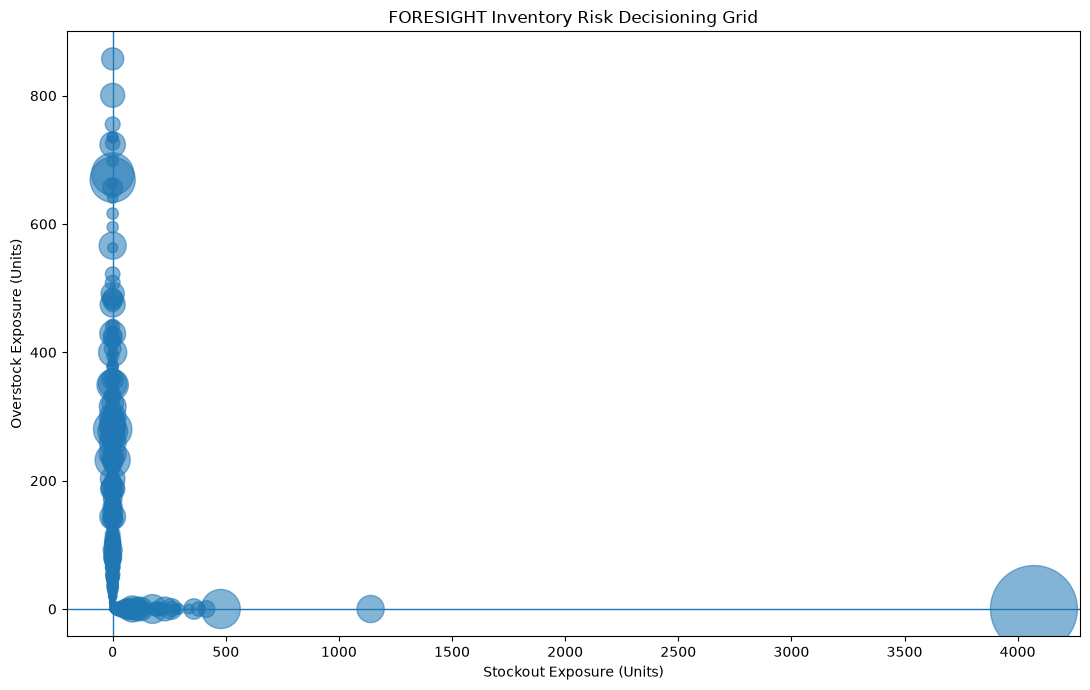

Saved: c:\Users\shiva\OneDrive\Desktop\Company\foresight-demand-inventory-intelligence\reports\figures\d4_decisioning_grid.png


In [17]:
risk_output["stockout_score_units"] = (
    risk_output["stockout_gap_units"]
)

risk_output["overstock_score_units"] = (
    risk_output["excess_units"]
)

plt.figure(figsize=(11, 7))

plt.scatter(
    risk_output["stockout_score_units"],
    risk_output["overstock_score_units"],
    s=np.maximum(
        risk_output["priority_value_rupees"] / 1000,
        10
    ),
    alpha=0.55
)

plt.xlabel("Stockout Exposure (Units)")
plt.ylabel("Overstock Exposure (Units)")
plt.title("FORESIGHT Inventory Risk Decisioning Grid")

plt.axvline(0, linewidth=1)
plt.axhline(0, linewidth=1)

plt.tight_layout()

decision_grid_path = (
    FIGURES_DIR / "d4_decisioning_grid.png"
)

plt.savefig(
    decision_grid_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", decision_grid_path)


## 16. Highest-Priority SKU Risks

This table provides the first operational review list.


In [18]:
top_risk = risk_output[
    [
        "sku_id",
        "category",
        "decision_quadrant",
        "recommended_action",
        "stockout_gap_units",
        "excess_units",
        "sales_at_risk_rupees",
        "locked_capital_rupees",
        "priority_value_rupees",
    ]
].head(25)

top_risk


,sku_id,category,decision_quadrant,recommended_action,stockout_gap_units,excess_units,sales_at_risk_rupees,locked_capital_rupees,priority_value_rupees
0,SKU04321,Personal Care,Reorder Now,Raise replenishment order,4072.111483,0.000000,3.914521e+06,0.000000e+00,3.914521e+06
1,SKU03941,Electronics & Accessories,Markdown / Clear,Review markdown / clearance,0.000000,668.988494,0.000000e+00,1.056018e+06,1.056018e+06
2,SKU01971,Apparel & Footwear,Markdown / Clear,Review markdown / clearance,0.000000,677.982877,0.000000e+00,9.282467e+05,9.282467e+05
3,SKU03727,Electronics & Accessories,Reorder Now,Raise replenishment order,477.718370,0.000000,7.934568e+05,0.000000e+00,7.934568e+05
4,SKU04062,Electronics & Accessories,Markdown / Clear,Review markdown / clearance,0.000000,280.041122,0.000000e+00,7.642154e+05,7.642154e+05
5,SKU03150,Apparel & Footwear,Markdown / Clear,Review markdown / clearance,0.000000,232.090641,0.000000e+00,6.365364e+05,6.365364e+05
6,SKU01174,Home & Kitchen,Markdown / Clear,Review markdown / clearance,0.000000,349.191555,0.000000e+00,5.108079e+05,5.108079e+05
7,SKU00024,Electronics & Accessories,Markdown / Clear,Review markdown / clearance,0.000000,277.096462,0.000000e+00,4.632942e+05,4.632942e+05
8,SKU04329,Home & Kitchen,Reorder Now,Raise replenishment order,176.119590,0.000000,4.318576e+05,0.000000e+00,4.318576e+05
9,SKU03833,Electronics & Accessories,Markdown / Clear,Review markdown / clearance,0.000000,350.910148,0.000000e+00,4.138003e+05,4.138003e+05


## 17. Save D4 Outputs


In [19]:
risk_output_path = REPORTS_DIR / "inventory_risk.csv"
summary_path = REPORTS_DIR / "inventory_action_summary.csv"

risk_output.to_csv(
    risk_output_path,
    index=False
)

decision_summary.to_csv(
    summary_path,
    index=False
)

print("Saved:", risk_output_path)
print("Saved:", summary_path)


Saved: c:\Users\shiva\OneDrive\Desktop\Company\foresight-demand-inventory-intelligence\reports\inventory_risk.csv
Saved: c:\Users\shiva\OneDrive\Desktop\Company\foresight-demand-inventory-intelligence\reports\inventory_action_summary.csv


## D4 Completion Checklist

- [x] Stockout risk for every SKU
- [x] Overstock risk for every SKU
- [x] Recommended action
- [x] Rupee sales-at-risk
- [x] Rupee locked-capital exposure
- [x] Transparent decision rules
- [x] Four decision quadrants
- [x] 5,000-SKU validation
- [x] Decisioning grid saved as PNG
- [x] Risk output saved to `reports/`
